# 🚗 Car Price Prediction using Machine Learning

## CodeAlpha Data Science Internship

### Author
MD SABIR

### Objective
To predict the selling price of used cars using Machine Learning.

In [39]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/car data.csv")

In [3]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

## Fuel Type Distribution

### Objective
To understand how cars are distributed across different fuel types.

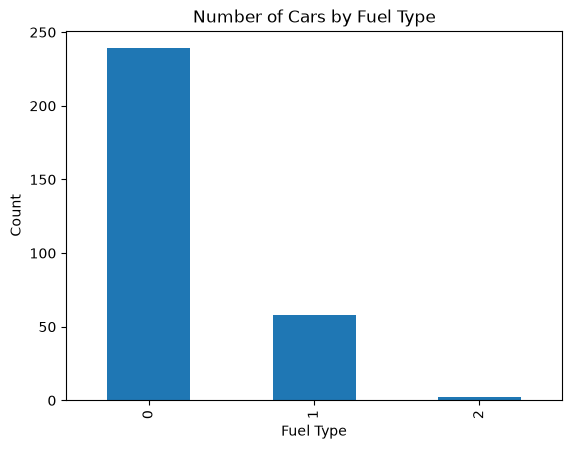

In [51]:
import matplotlib.pyplot as plt

df['Fuel_Type'].value_counts().plot(kind='bar')

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.savefig("../images/fuel_type_distribution.png")

plt.show()

### Observation

- Petrol cars are the most common in the dataset.
- Diesel cars are fewer than Petrol cars.
- CNG cars are very rare.

### Insight

The dataset is dominated by Petrol vehicles, indicating that the machine learning model will have significantly more Petrol car examples than CNG cars.

## 📊 Selling Price Distribution

### Objective
Analyze the distribution of car selling prices to understand how prices are spread across the dataset and identify whether most cars have low, medium, or high selling prices.

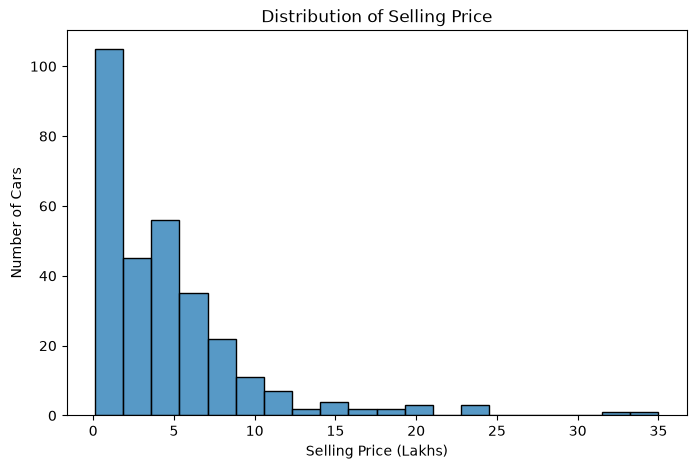

In [50]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], bins=20)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.savefig("../images/selling_price_distribution.png")

plt.show()

### Observation

- Most cars are concentrated within a specific selling price range.
- High-priced cars are fewer compared to low- and mid-priced cars.
- The selling prices are not evenly distributed.

### Insight

Most cars in the dataset belong to the lower and medium price segments, indicating that the dataset is dominated by affordable used cars. Only a small number of cars fall into the premium price range.

## 📈 Present Price vs Selling Price

### Objective
Analyze the relationship between a car's present price and its selling price to determine whether cars with higher present prices tend to have higher selling prices.

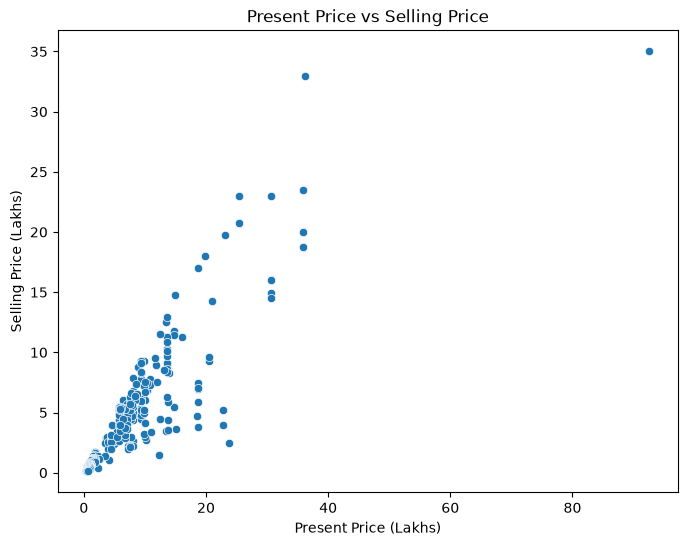

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.savefig("../images/present_price_vs_selling_price.png")

plt.show()

### Observation

- There is a positive relationship between Present Price and Selling Price.
- Cars with higher present prices generally have higher selling prices.
- Most cars are concentrated in the lower price range (below 20 lakhs).
- A few expensive cars act as outliers in the dataset.

### Insight

Present Price is likely to be one of the most important features for predicting Selling Price. As the present price of a car increases, its selling price also tends to increase.

## 📉 Driven Kilometers vs Selling Price

### Objective

Analyze the relationship between the number of kilometers driven and the selling price of a car to understand whether higher mileage affects the resale value.

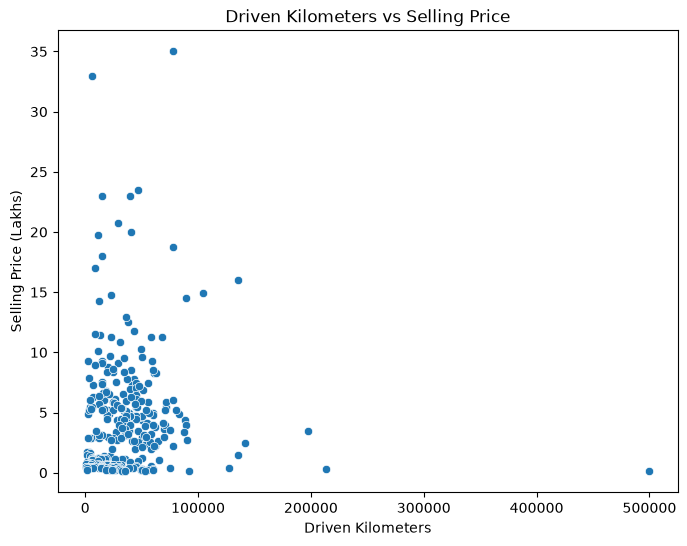

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Driven_kms',
    y='Selling_Price',
    data=df
)

plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price (Lakhs)")

plt.savefig("../images/driven_kms_vs_selling_price.png")

plt.show()

### Observation

- A weak to moderate negative relationship exists between Driven_kms and Selling_Price.
- Cars with higher mileage generally tend to have lower selling prices.
- The data points are widely scattered, indicating that other factors also influence the selling price.
- A few outliers with extremely high mileage or unusually high selling prices are present in the dataset.

### Insight

Driven_kms has an impact on the selling price of a car, but it is not the only deciding factor. Other features such as Present_Price, Year, Fuel_Type, and Transmission also contribute to the resale value.

## 📅 Year vs Selling Price

### Objective

Analyze the relationship between the manufacturing year of a car and its selling price to understand whether newer cars generally have higher resale values than older cars.

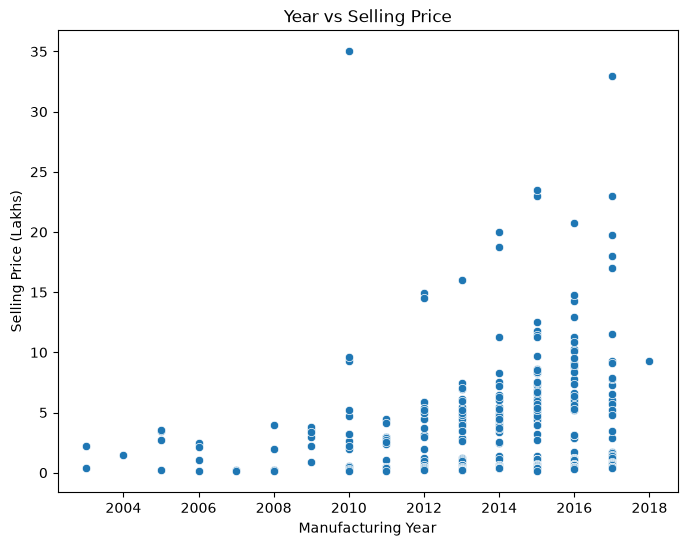

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=df
)

plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price (Lakhs)")

plt.savefig("../images/year_vs_selling_price.png")

plt.show()

### Observation

- A positive relationship exists between Manufacturing Year and Selling Price.
- Newer cars generally have higher selling prices than older cars.
- Older vehicles are mostly concentrated in the lower selling price range.
- A few high-value cars appear as outliers in the dataset.

### Insight

Manufacturing Year is an important feature for predicting Selling Price because newer cars generally retain more value due to lower depreciation and improved technology.

## ⚙️ Transmission Distribution

### Objective

Analyze the distribution of transmission types (Manual and Automatic) to understand which transmission is more common in the dataset.

In [19]:
df['Transmission'].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

### Observation

- Manual transmission cars dominate the dataset with 261 vehicles.
- Automatic transmission cars are much fewer, with only 40 vehicles.
- This indicates that manual transmission is the most common transmission type in the dataset.

### Insight

The dataset is heavily dominated by manual transmission vehicles. This reflects the historical popularity of manual cars in the used car market during the years covered by the dataset.

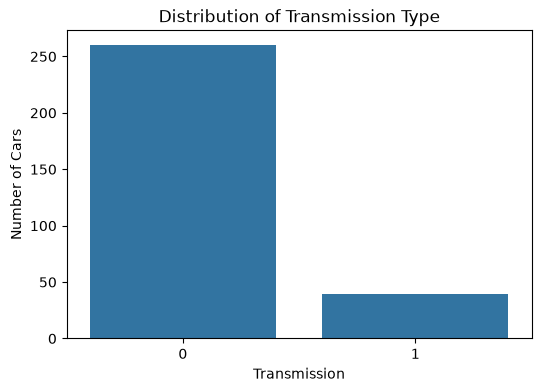

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Transmission')

plt.title("Distribution of Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.savefig("../images/transmission_distribution.png")

plt.show()

## 🏪 Selling Type Distribution

### Objective

Analyze the distribution of selling types (Dealer and Individual) to understand which selling method is more common in the dataset.

In [22]:
df['Selling_type'].value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

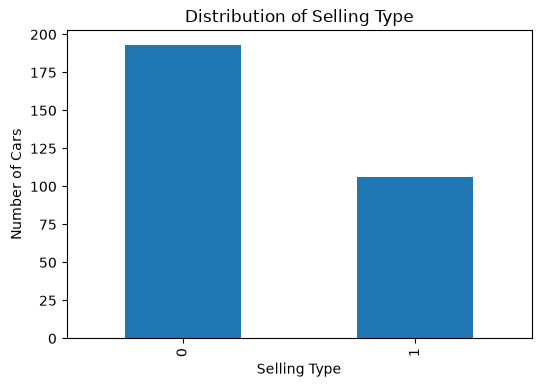

In [45]:
plt.figure(figsize=(6,4))

df['Selling_type'].value_counts().plot(kind='bar')

plt.title("Distribution of Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Number of Cars")

plt.savefig("../images/selling_type_distribution.png")

plt.show()

### Observation

- Dealer sales are more common than individual sales in the dataset.
- The dataset contains 195 dealer sales and 106 individual sales.
- This indicates that dealers account for the majority of used car transactions in this dataset.

### Insight

One possible reason is that dealerships often manage a larger inventory of used cars and facilitate more transactions than individual sellers. As a result, dealer sales are more strongly represented in this dataset.

## 🔥 Correlation Heatmap

### Objective

Analyze the correlation between numerical features to identify which variables have the strongest relationship with the selling price.

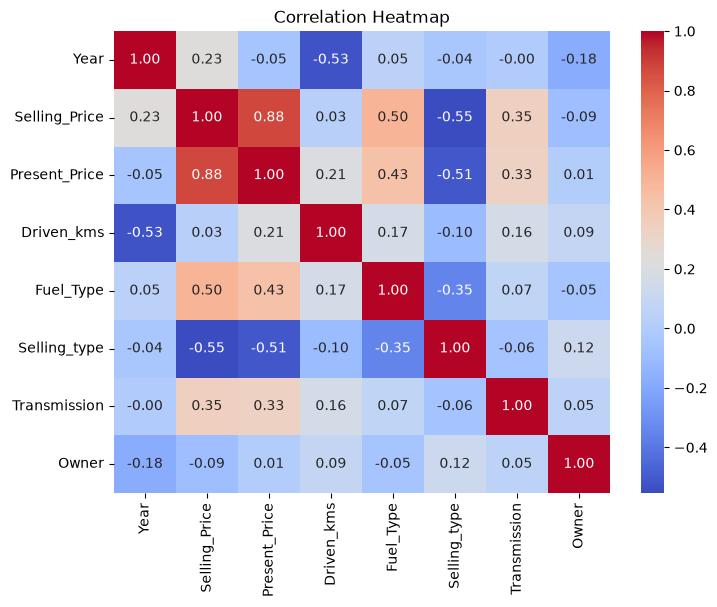

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")

plt.show()

### Observation

- Present_Price has the strongest positive correlation with Selling_Price (0.88).
- Year has a weak positive correlation with Selling_Price (0.24).
- Driven_kms has a very weak correlation with Selling_Price (0.03).
- Year and Driven_kms have a moderate negative correlation (-0.52), indicating that newer cars generally have lower mileage.

### Insight

The heatmap indicates that Present_Price is the most influential feature for predicting Selling_Price. While Year has a positive impact, Driven_kms alone has a very weak relationship with Selling_Price, suggesting that resale value depends on multiple factors rather than mileage alone.

# 🧹 Data Preprocessing

## 📌 Checking Missing Values

### Objective

Identify whether the dataset contains any missing (null) values that could affect machine learning model performance.

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Observation

No missing values were found in the dataset. Every column contains complete data with 301 non-null entries.

### Insight

Since the dataset contains no missing values, no data imputation or removal of missing records is required before training the machine learning model.

## 📌 Checking Duplicate Values

### Objective

Identify duplicate records in the dataset and remove them if necessary to improve data quality before training the machine learning model.

In [8]:
df.duplicated().sum()

np.int64(2)

### Observation

The dataset contains **2 duplicate rows**.

### Insight

Duplicate records can introduce bias into the machine learning model because the same information is repeated. Therefore, removing duplicate rows improves the quality of the dataset.

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(299, 9)

# 🔢 Encoding Categorical Features

## 📌 Objective

Convert categorical (text) features into numerical values so that they can be used by machine learning algorithms.

In [11]:
df = df.drop('Car_Name', axis=1)

In [12]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

## 🔍 Exploring Categorical Features

### Objective

Identify the unique categories present in each categorical feature before converting them into numerical values.

In [13]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [14]:
df['Selling_type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [15]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

## 🔢 Label Encoding

### Objective

Convert categorical features into numerical values so that machine learning algorithms can process the dataset.


In [16]:
df.replace({
    'Fuel_Type': {
        'Petrol': 0,
        'Diesel': 1,
        'CNG': 2
    },
    'Selling_type': {
        'Dealer': 0,
        'Individual': 1
    },
    'Transmission': {
        'Manual': 0,
        'Automatic': 1
    }
}, inplace=True)

C:\Users\iamsa\AppData\Local\Temp\ipykernel_14380\1939793188.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [17]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,1,0,0,0
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,1,0,0,0


# 🎯 Feature Selection

## 📌 Objective

Separate the independent variables (features) from the dependent variable (target) for machine learning model training.

In [18]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

In [19]:
X.head()


,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,5.59,27000,0,0,0,0
1,2013,9.54,43000,1,0,0,0
2,2017,9.85,6900,0,0,0,0
3,2011,4.15,5200,0,0,0,0
4,2014,6.87,42450,1,0,0,0


In [20]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [27]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

X.head()

y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

# ✂️ Train-Test Split

## 📌 Objective

Split the dataset into training and testing sets so that the machine learning model can learn from one portion of the data and be evaluated on unseen data.

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(239, 7)
(60, 7)
(239,)
(60,)


# 🤖 Linear Regression Model

## 📌 Objective

Train a Linear Regression model to learn the relationship between car features and selling price, enabling it to predict the selling price of unseen cars.

In [28]:
from sklearn.linear_model import LinearRegression


In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.34, 0.44,-0. ,...,-1.29, 1.58, 0.7 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Year','Present_Price','Driven_kms',...,'Selling_type','Transmission', 'Owner']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-687.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


# 🔮 Making Predictions

## 📌 Objective

Use the trained Linear Regression model to predict the selling prices of cars in the testing dataset.

In [31]:
y_pred = model.predict(X_test)

In [32]:
print(y_pred[:5])

[ 7.54014502  7.60794295  1.36086701  6.83816158 11.26433156]


# 📊 Model Evaluation

## 📌 Objective

Compare the predicted selling prices with the actual selling prices to evaluate the performance of the Linear Regression model.

In [33]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,7.540145
1,8.35,7.607943
2,0.45,1.360867
3,7.45,6.838162
4,5.25,11.264332
5,5.25,4.543315
6,5.85,8.583769
7,1.15,1.707565
8,9.25,8.645293
9,0.38,-0.941602


# 📈 Model Evaluation

## 📌 Objective

Evaluate the performance of the Linear Regression model using standard regression metrics.

In [34]:
from sklearn.metrics import mean_absolute_error

In [35]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.5408119549692783


# 📊 R² Score

## 📌 Objective

Measure how well the Linear Regression model explains the variation in selling prices.

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.7409934356413088


# 📊 Actual Price vs Predicted Price

## 📌 Objective

Visualize the relationship between the actual selling prices and the predicted selling prices to evaluate how closely the model's predictions match the real values.

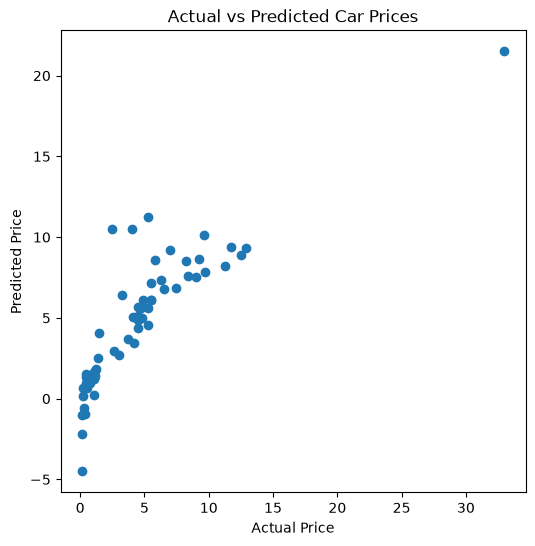

In [43]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.savefig("../images/actual_vs_predicted.png")

plt.show()

# 💾 Saving the Trained Model

## 📌 Objective

Save the trained Linear Regression model so it can be reused later without retraining.

In [41]:
import joblib

In [42]:
joblib.dump(model, "../models/car_price_model.pkl")

['../models/car_price_model.pkl']